# Raw RF → B-mode reconstruction & RF tissue characterisation

This notebook turns raw ultrasound **RF** data (and pre-detected **envelope** data)
into a scan-converted B-mode image, then uses the *frequency content of the raw RF*
to cluster the image into tissue classes (soft tissue / muscle / fluid / strong
reflectors).

**Pipeline**

1. `load_rf_csv` — read the `Line, Sample_0 …` CSV (no pandas needed).
2. `rf_to_envelope` — bandpass + Hilbert envelope detection (raw RF only).
3. `envelope_to_bmode` — TGC + log compression in polar (beam × sample) space.
4. `scan_convert` — polar → cartesian convex fan.
5. `postprocess_bmode` — despeckle (median + bilateral + mild CLAHE).
6. `tissue_features` + `cluster_tissues` — per-pixel RF features → KMeans tissue map.

The functions are deliberately **small and composable** so the same intermediate
results (raw RF, envelope, geometry) feed both the image and the clustering.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.signal import hilbert, butter, filtfilt
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter, uniform_filter
import cv2
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Acquisition constants for this probe (override per call if needed)
FS = 30e6          # sampling rate [Hz]
C  = 1540.0        # speed of sound [m/s]
CENTER_FREQ = 3e6  # probe centre frequency [Hz]
SECTOR_DEG  = 70   # sector opening angle [deg]
RCURV_MM    = 65   # convex-probe radius of curvature [mm]  (0 -> pointed-apex fan)

## 1. Loading

The probe writes **signed `int16`** RF samples into an **unsigned** CSV field, so a
raw value like `64557` is really `-979`. `load_rf_csv(..., signed=True)` reinterprets
the bits back to signed. Envelope files (values already 0–255) use `signed=False`.

> Rule of thumb: files with `_rawRF` in the name are raw RF (`signed=True`); the
> rest are envelope data (`signed=False`).

In [2]:
def load_rf_csv(filepath, signed=True):
    '''Load a `Line, Sample_0, ...` CSV into a (num_beams, num_samples) array.

    signed=True  -> raw RF: stored uint16 reinterpreted as signed int16
                    (the probe writes signed samples into an unsigned field).
    signed=False -> envelope data (already 0..255), returned as float as-is.
    '''
    raw = np.genfromtxt(filepath, delimiter=",", skip_header=1, filling_values=0.0)
    if raw.ndim == 1:
        raw = raw[np.newaxis, :]
    data = raw[:, 1:]                     # drop the 'Line' beam-index column
    if signed:
        data = data.astype(np.uint16).view(np.int16).astype(np.float64)
    else:
        data = data.astype(np.float64)
    return data

## 2. Signal processing (polar beam × sample space)

For raw RF we band-pass around the centre frequency and take the analytic-signal
envelope. Then TGC (depth gain) + log compression map the envelope to a `[0, 1]`
B-mode. These stay in polar space — scan conversion happens later, so the same
arrays can also be fed to the tissue-feature extractor.

In [3]:
def rf_to_envelope(data, fs=FS, center_freq=CENTER_FREQ, fractional_bw=0.4):
    '''Bandpass raw RF then Hilbert-detect the envelope. Returns (envelope, filtered).'''
    nyq  = fs / 2
    low  = np.clip(center_freq * (1 - fractional_bw / 2) / nyq, 1e-4, 0.9999)
    high = np.clip(center_freq * (1 + fractional_bw / 2) / nyq, 1e-4, 0.9999)
    b, a = butter(6, [low, high], btype="band")
    filtered = filtfilt(b, a, data, axis=1)
    envelope = np.abs(hilbert(filtered, axis=1))
    print(f"Bandpass {low*nyq/1e6:.2f}-{high*nyq/1e6:.2f} MHz | "
          f"envelope range [{envelope.min():.1f}, {envelope.max():.1f}]")
    return envelope, filtered


def envelope_to_bmode(envelope, dynamic_range=45, tgc_exponent=1.5):
    '''TGC + log-compress an envelope to a [0,1] B-mode (still in polar space).'''
    n = envelope.shape[1]
    tgc = (np.arange(n) / (n - 1)) ** tgc_exponent + 1.0
    env = envelope * tgc[np.newaxis, :]
    env = env / (env.max() + 1e-12)
    bmode = 20 * np.log10(env + 1e-6)
    bmode = np.clip(bmode, -dynamic_range, 0.0)
    bmode = (bmode + dynamic_range) / dynamic_range
    return bmode

## 3. Scan conversion (polar → cartesian fan)

`scan_convert` maps the polar grid (`theta` × `depth`) onto a cartesian image.
For a convex probe (`curvature_radius_mm > 0`) the apex sits *below* the curved
face. It returns the cartesian image, the sector mask, and a matplotlib `extent`
in cm so axes read out real distances. The depth axis is auto-cropped to where
there is actual signal so the fan fills the frame.

`scan_convert` is generic — feed it a B-mode for the image, or a label map
(`method="nearest"`) to scan-convert the tissue clusters with the same geometry.

In [4]:
def scan_convert(polar, sector_angle_deg=SECTOR_DEG, curvature_radius_mm=RCURV_MM,
                 fs=FS, c=C, output_resolution=(1024, 1024),
                 envelope_for_crop=None, fill_value=0.0, method="linear"):
    '''Convert a (beams, samples) polar image to a cartesian fan.

    Returns (cart, mask, extent_cm) where extent_cm = [xmin, xmax, ymax, ymin]
    (cm) for imshow. Pass envelope_for_crop to auto-crop depth to active signal.
    '''
    num_beams, num_samples = polar.shape
    sector   = np.deg2rad(sector_angle_deg)
    dr       = c / (2 * fs)
    depths_m = np.arange(num_samples) * dr
    Rcurv    = curvature_radius_mm / 1000.0
    theta    = np.linspace(-sector / 2, sector / 2, num_beams)
    max_depth = depths_m[-1]

    if envelope_for_crop is not None:
        thr = 0.01 * envelope_for_crop.max()
        active = np.where(envelope_for_crop.max(axis=0) > thr)[0]
        active_depth = depths_m[active[-1]] if len(active) else max_depth
        display_depth = min(active_depth * 1.05, max_depth)
    else:
        display_depth = max_depth

    # Cartesian bounds of the *displayed* fan. For a convex probe the curved face
    # dips ABOVE y=0 at the sector edges, so the true top is negative; the deepest
    # point is the centre beam at y = display_depth. Cropping the canvas to these
    # exact bounds removes the black margins that made the fan look short/clipped.
    y_top = Rcurv * (np.cos(sector / 2) - 1)          # <= 0 : top corners of curved face
    y_bot = display_depth                              # centre beam, deepest sample
    x_max = (Rcurv + display_depth) * np.sin(sector / 2)
    x_lin = np.linspace(-x_max, x_max, output_resolution[1])
    y_lin = np.linspace(y_top, y_bot, output_resolution[0])
    Xg, Yg = np.meshgrid(x_lin, y_lin)

    if Rcurv > 0:
        r_grid     = np.sqrt(Xg ** 2 + (Yg + Rcurv) ** 2)
        theta_grid = np.arctan2(Xg, Yg + Rcurv)
        depth_grid = r_grid - Rcurv
    else:
        r_grid     = np.sqrt(Xg ** 2 + Yg ** 2)
        theta_grid = np.arctan2(Xg, Yg)
        depth_grid = r_grid

    interp = RegularGridInterpolator((theta, depths_m), polar,
                                     method=method, bounds_error=False,
                                     fill_value=fill_value)
    cart = interp(np.column_stack((theta_grid.ravel(), depth_grid.ravel()))
                  ).reshape(output_resolution)

    if Rcurv > 0:
        mask = ((np.abs(theta_grid) <= sector / 2) &
                (r_grid >= Rcurv) & (r_grid <= Rcurv + max_depth))
    else:
        mask = (np.abs(theta_grid) <= sector / 2) & (r_grid <= max_depth)

    extent_cm = [x_lin[0] * 100, x_lin[-1] * 100, y_lin[-1] * 100, y_lin[0] * 100]
    return np.where(mask, cart, fill_value), mask, extent_cm


def postprocess_bmode(cart_masked):
    '''Edge-preserving despeckle: median + bilateral + mild CLAHE. Returns float [0,1].'''
    img8 = np.clip(cart_masked * 255, 0, 255).astype(np.uint8)
    img8 = cv2.medianBlur(img8, 3)                              # kill salt-and-pepper
    img8 = cv2.bilateralFilter(img8, d=5, sigmaColor=25, sigmaSpace=50)  # smooth, keep edges
    img8 = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8)).apply(img8)
    return img8.astype(np.float32) / 255.0

## 4. One-call reconstruction

`reconstruct` wires the steps together and returns a dict with every intermediate
(`data`, `envelope`, `bmode_polar`, `bmode_cart`, `extent`, geometry). Keeping the
intermediates around means the tissue-clustering section can reuse the exact same
envelope and geometry instead of recomputing them.

In [5]:
def reconstruct(filepath, signed=True, center_freq=CENTER_FREQ, fractional_bw=0.4,
                dynamic_range=45, tgc_exponent=1.5,
                sector_angle_deg=SECTOR_DEG, curvature_radius_mm=RCURV_MM,
                fs=FS, c=C, output_resolution=(1024, 1024)):
    '''Full RF/envelope -> displayed B-mode. Returns a dict of all intermediates.'''
    data = load_rf_csv(filepath, signed=signed)
    print(f"Loaded {data.shape[0]} beams x {data.shape[1]} samples "
          f"({'raw RF' if signed else 'envelope'})")

    if signed:
        envelope, filtered = rf_to_envelope(data, fs=fs, center_freq=center_freq,
                                            fractional_bw=fractional_bw)
    else:
        envelope, filtered = data.copy(), None

    bmode_polar = gaussian_filter(
        envelope_to_bmode(envelope, dynamic_range=dynamic_range, tgc_exponent=tgc_exponent),
        sigma=0.5)
    bmode_cart, mask, extent = scan_convert(
        bmode_polar, sector_angle_deg=sector_angle_deg,
        curvature_radius_mm=curvature_radius_mm, fs=fs, c=c,
        output_resolution=output_resolution, envelope_for_crop=envelope)
    final = postprocess_bmode(bmode_cart)

    return dict(data=data, filtered=filtered, envelope=envelope,
                bmode_polar=bmode_polar, bmode_cart=final, mask=mask, extent=extent,
                fs=fs, c=c, sector_angle_deg=sector_angle_deg,
                curvature_radius_mm=curvature_radius_mm,
                output_resolution=output_resolution)


def show_bmode(res, title="Convex B-mode reconstruction"):
    '''Display a reconstruction dict's B-mode with cm axes.'''
    ext = res["extent"]
    aspect = (ext[1] - ext[0]) / (ext[2] - ext[3])
    fig, ax = plt.subplots(figsize=(max(8 * aspect, 4), 8))
    im = ax.imshow(res["bmode_cart"], cmap="gray", extent=ext, aspect="auto")
    ax.set_xlabel("Lateral (cm)"); ax.set_ylabel("Depth (cm)"); ax.set_title(title)
    fig.colorbar(im, ax=ax, label="Normalised intensity")
    fig.tight_layout(); plt.show()

## 5. Run the reconstruction

Point this at a `_rawRF.csv` (raw RF, `signed=True`) or an envelope CSV
(`signed=False`). Tune `fractional_bw` (passband width), `dynamic_range`
(contrast / noise-floor) and `curvature_radius_mm` (probe geometry).

Loaded 127 beams x 2048 samples (raw RF)
Bandpass 2.40-3.60 MHz | envelope range [0.0, 2821.1]


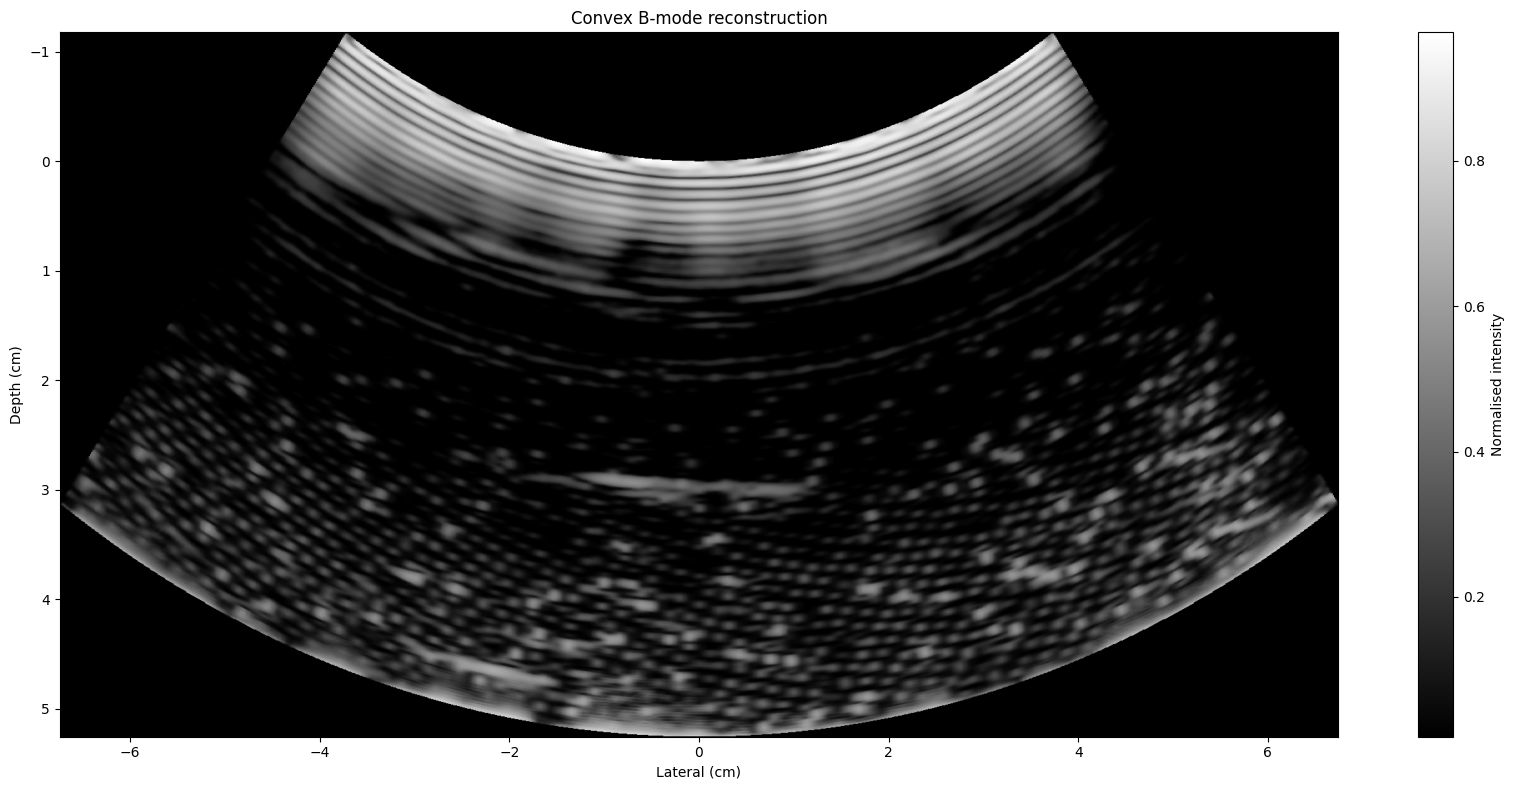

In [6]:
RAW_FILE = "frame_20260328_070217_4784_0001_rawRF.csv"

res = reconstruct(
    RAW_FILE,
    signed=True,
    center_freq=3e6,        # probe centre frequency
    fractional_bw=0.4,      # passband 2.4-3.6 MHz
    dynamic_range=45,       # contrast / noise-floor in dB
    tgc_exponent=1.5,
    sector_angle_deg=70,
    curvature_radius_mm=65,
    output_resolution=(1024, 1024),
)
show_bmode(res)

## 6. RF tissue characterisation

Unlike envelope data, **raw RF carries frequency information** — and different
tissues scatter/attenuate differently across the band. We build a per-pixel
feature vector (in polar space, where the RF lives) from:

| Feature | What it captures | Tissue cue |
|---|---|---|
| **brightness** (local mean log-envelope) | echo strength | fluid/anechoic (low) vs solid tissue vs bone (high) |
| **texture_std** (local std) | speckle roughness | smooth fluid vs grainy muscle/fat |
| **spectral_centroid** (mean RF frequency) | frequency-dependent backscatter | tissue type & attenuation |
| **spectral_bandwidth** (RF spectral spread) | scatterer regularity | organised (muscle fibres) vs random |

`spectral_features` runs a short-time FFT down each beam, so frequency features
are spatially resolved with depth.

In [7]:
def spectral_features(rf, fs=FS, win=64, step=16):
    '''Per-sample spectral centroid & bandwidth via short-time FFT along depth.
    Returns two (beams, samples) maps interpolated back onto the full sample axis.'''
    nb, ns  = rf.shape
    centers = np.arange(win // 2, ns - win // 2, step)
    freqs   = np.fft.rfftfreq(win, d=1 / fs)
    hann    = np.hanning(win)
    cen = np.zeros((nb, len(centers)))
    bw  = np.zeros((nb, len(centers)))
    for j, cidx in enumerate(centers):
        seg = rf[:, cidx - win // 2: cidx + win // 2] * hann[np.newaxis, :]
        ps  = np.abs(np.fft.rfft(seg, axis=1)) ** 2
        psum = ps.sum(axis=1) + 1e-12
        fc  = (ps * freqs[np.newaxis, :]).sum(axis=1) / psum
        var = (ps * (freqs[np.newaxis, :] - fc[:, None]) ** 2).sum(axis=1) / psum
        cen[:, j], bw[:, j] = fc, np.sqrt(var)
    full = np.arange(ns)
    cen_full = np.array([np.interp(full, centers, cen[b]) for b in range(nb)])
    bw_full  = np.array([np.interp(full, centers, bw[b])  for b in range(nb)])
    return cen_full, bw_full


def tissue_features(rf, envelope, fs=FS):
    '''Stack per-pixel features for clustering (all in polar beam x sample space).'''
    log_env = np.log1p(envelope)
    log_env_n = log_env / (log_env.max() + 1e-12)
    local_mean = uniform_filter(log_env_n, size=(3, 9))
    local_sq   = uniform_filter(log_env_n ** 2, size=(3, 9))
    local_std  = np.sqrt(np.maximum(local_sq - local_mean ** 2, 0))
    cen, bw = spectral_features(rf, fs=fs)
    return {"brightness": local_mean, "texture_std": local_std,
            "spectral_centroid": cen, "spectral_bandwidth": bw}

### Visualise the raw feature maps

Before clustering, look at each feature in polar space (beams across, depth down)
to confirm they carry structure.

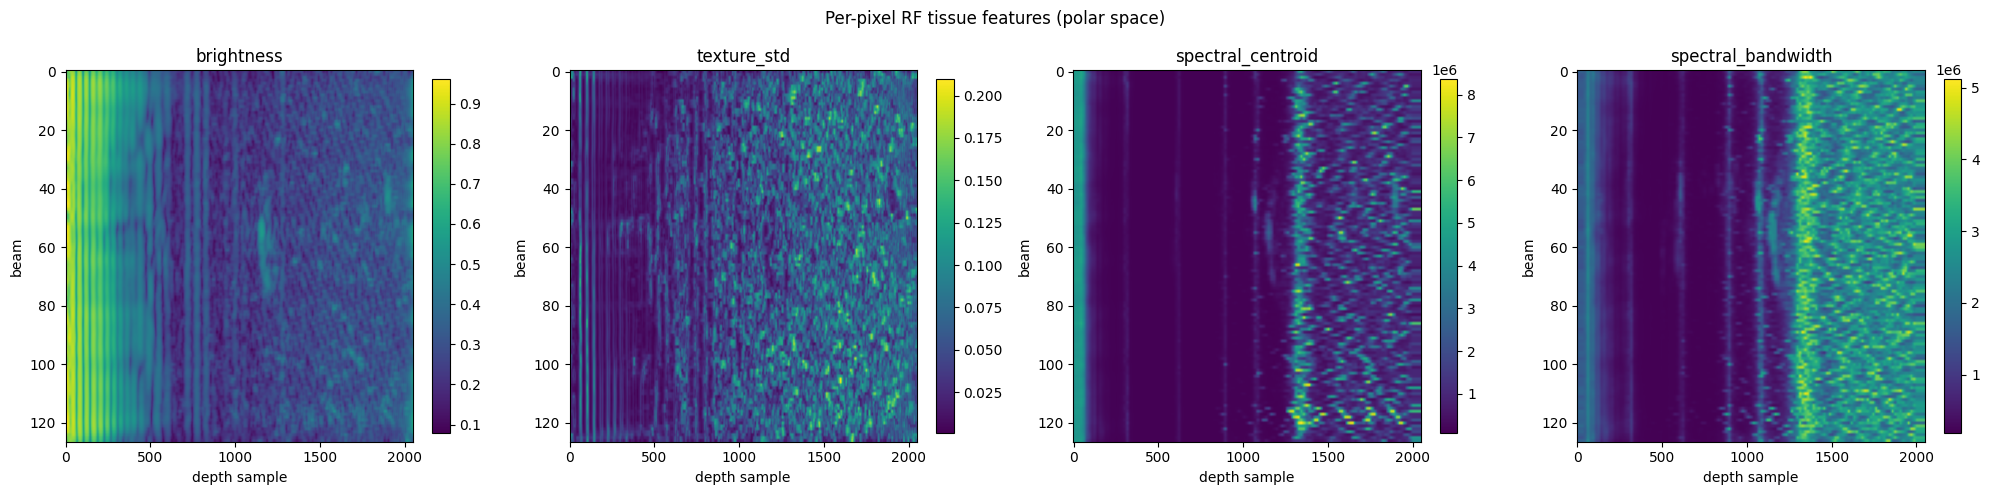

In [8]:
feats = tissue_features(res["data"], res["envelope"])

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, fmap) in zip(axs, feats.items()):
    im = ax.imshow(fmap, aspect="auto", cmap="viridis")
    ax.set_title(name); ax.set_xlabel("depth sample"); ax.set_ylabel("beam")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Per-pixel RF tissue features (polar space)")
fig.tight_layout(); plt.show()

### Cluster into tissue classes

KMeans over the standardised feature stack. Clusters are re-ordered by mean
brightness so labels are stable and interpretable (0 = darkest/low-echo →
`n_clusters-1` = brightest/strong reflector). The signal mask restricts
clustering to the insonified depth band; low-echo regions are *kept* so they can
form their own (fluid/anechoic) class rather than being thrown away.

In [9]:
def cluster_tissues(feats, n_clusters=4, signal_mask=None, seed=0):
    '''KMeans over standardised features. Returns a (beams, samples) label map
    (-1 outside the mask), brightness-ordered so colours are interpretable.'''
    shape = next(iter(feats.values())).shape
    X  = np.stack([f.ravel() for f in feats.values()], axis=1)
    Xs = StandardScaler().fit_transform(X)
    if signal_mask is None:
        signal_mask = np.ones(shape, dtype=bool)
    flat = signal_mask.ravel()

    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    labels = np.full(X.shape[0], -1, dtype=int)
    labels[flat] = km.fit_predict(Xs[flat])

    bright = feats["brightness"].ravel()
    order = np.argsort([bright[labels == k].mean() if (labels == k).any() else 0
                        for k in range(n_clusters)])
    remap = {old: new for new, old in enumerate(order)}
    out = labels.copy()
    for old, new in remap.items():
        out[labels == old] = new
    return out.reshape(shape)


# insonified-depth signal mask (do NOT threshold on amplitude here)
env = res["envelope"]
active = np.where(env.max(axis=0) > 0.01 * env.max())[0]
active_max = active[-1] if len(active) else env.shape[1] - 1
sig_mask = np.zeros_like(env, dtype=bool)
sig_mask[:, :active_max + 1] = True

N_CLUSTERS = 4
labels_polar = cluster_tissues(feats, n_clusters=N_CLUSTERS, signal_mask=sig_mask)
print("cluster labels present:", np.unique(labels_polar))

cluster labels present: [0 1 2 3]


### Scan-convert the tissue map and overlay it on the B-mode

The label map goes through the *same* `scan_convert` (nearest-neighbour, so labels
stay integer). We show the B-mode, the tissue map, and a translucent overlay.

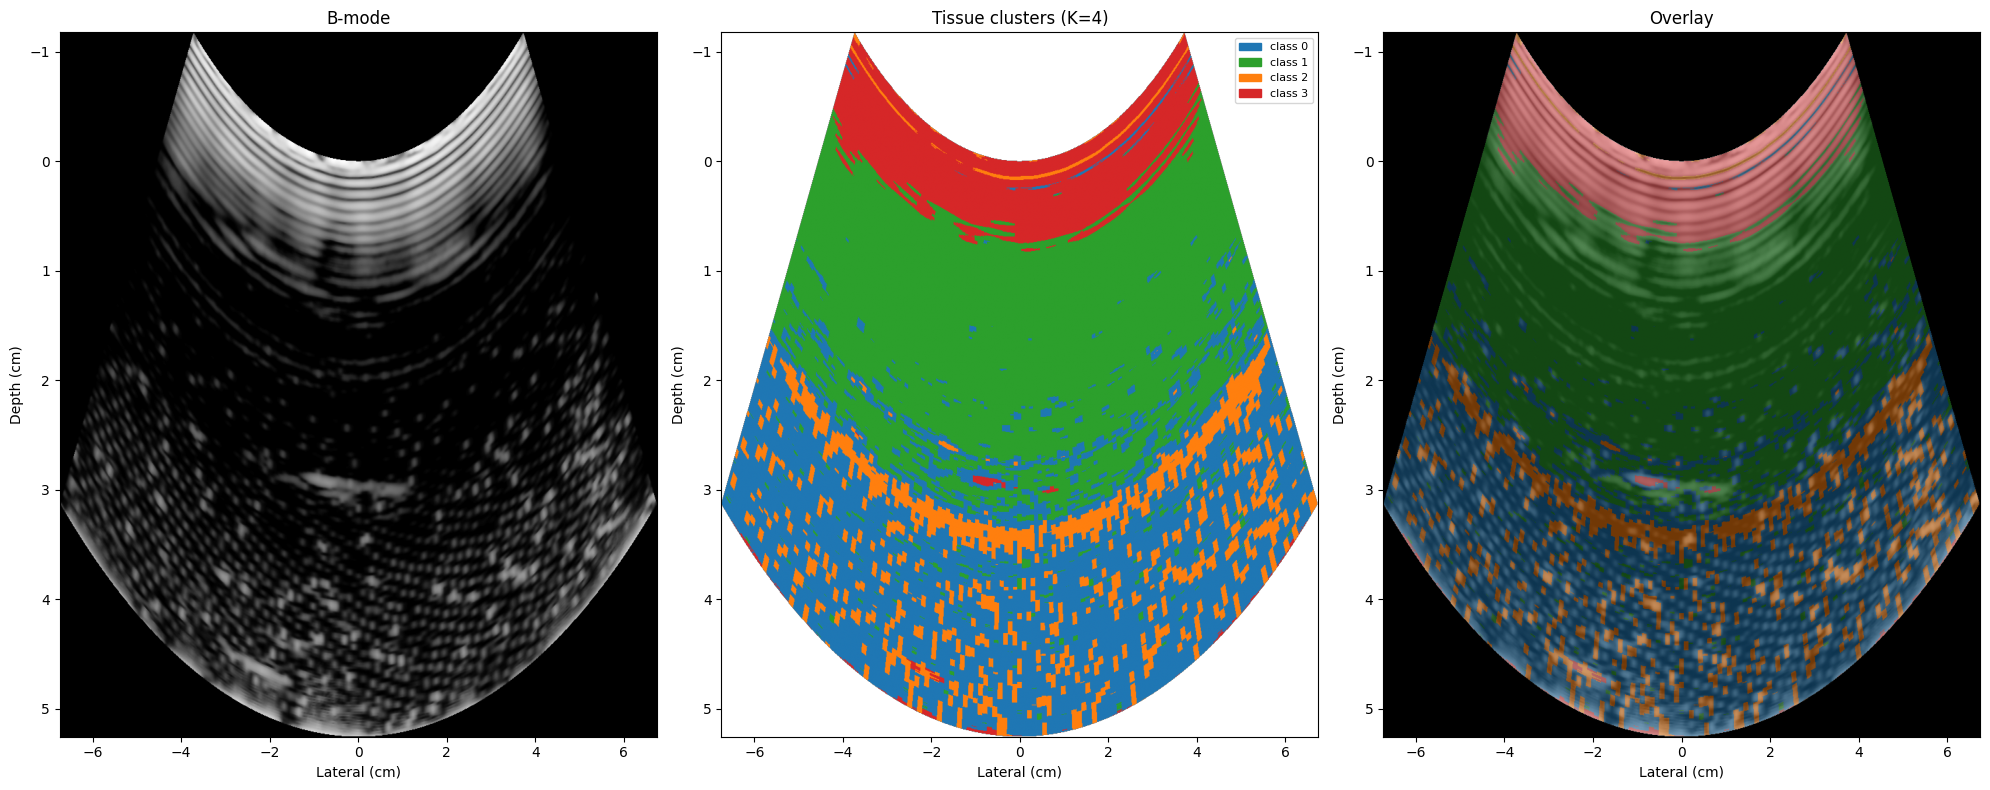

In [10]:
TISSUE_COLORS = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd", "#8c564b"]
cmap = ListedColormap(TISSUE_COLORS[:N_CLUSTERS])

# +1 so the fill_value 0 stays distinct from cluster 0, then shift back
lab_cart, _, ext2 = scan_convert(
    (labels_polar + 1).astype(float),
    sector_angle_deg=res["sector_angle_deg"], curvature_radius_mm=res["curvature_radius_mm"],
    fs=res["fs"], c=res["c"], output_resolution=res["output_resolution"],
    envelope_for_crop=res["envelope"], fill_value=0.0, method="nearest")
lab_cart = np.round(lab_cart).astype(int) - 1
masked_lab = np.ma.masked_less(lab_cart, 0)

fig, axs = plt.subplots(1, 3, figsize=(20, 8))
axs[0].imshow(res["bmode_cart"], cmap="gray", extent=res["extent"], aspect="auto")
axs[0].set_title("B-mode")
axs[1].imshow(masked_lab, cmap=cmap, extent=ext2, aspect="auto", vmin=0, vmax=N_CLUSTERS - 1)
axs[1].set_title(f"Tissue clusters (K={N_CLUSTERS})")
axs[2].imshow(res["bmode_cart"], cmap="gray", extent=res["extent"], aspect="auto")
axs[2].imshow(masked_lab, cmap=cmap, alpha=0.45, extent=ext2, aspect="auto",
              vmin=0, vmax=N_CLUSTERS - 1)
axs[2].set_title("Overlay")
for ax in axs:
    ax.set_xlabel("Lateral (cm)"); ax.set_ylabel("Depth (cm)")

handles = [plt.Rectangle((0, 0), 1, 1, color=TISSUE_COLORS[k]) for k in range(N_CLUSTERS)]
axs[1].legend(handles, [f"class {k}" for k in range(N_CLUSTERS)],
              loc="upper right", fontsize=8)
fig.tight_layout(); plt.show()

### Interpret the clusters

Mean feature values per class help label them physically (e.g. low brightness +
low texture ≈ fluid; high spectral centroid + organised texture ≈ muscle; very
high brightness ≈ strong reflector / connective tissue). Adjust `N_CLUSTERS` and
re-run to coarsen/refine the segmentation.

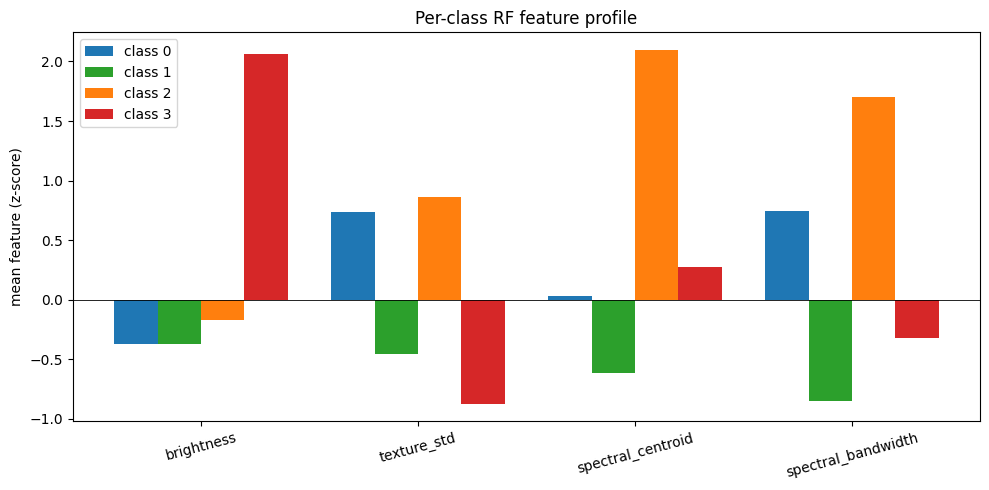

class 0:  31.9% of insonified pixels
class 1:  43.3% of insonified pixels
class 2:  10.3% of insonified pixels
class 3:  14.5% of insonified pixels


In [11]:
feat_names = list(feats.keys())
F = np.stack([f.ravel() for f in feats.values()], axis=1)
lab_flat = labels_polar.ravel()

# z-score each feature so they're comparable on one chart
Fz = (F - F.mean(0)) / (F.std(0) + 1e-12)
profiles = np.array([Fz[lab_flat == k].mean(0) for k in range(N_CLUSTERS)])

x = np.arange(len(feat_names)); w = 0.8 / N_CLUSTERS
fig, ax = plt.subplots(figsize=(10, 5))
for k in range(N_CLUSTERS):
    ax.bar(x + k * w, profiles[k], w, label=f"class {k}", color=TISSUE_COLORS[k])
ax.set_xticks(x + 0.4 - w / 2); ax.set_xticklabels(feat_names, rotation=15)
ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("mean feature (z-score)")
ax.set_title("Per-class RF feature profile")
ax.legend(); fig.tight_layout(); plt.show()

# also report the pixel share of each class within the fan
counts = np.array([(lab_flat == k).sum() for k in range(N_CLUSTERS)], float)
for k in range(N_CLUSTERS):
    print(f"class {k}: {100 * counts[k] / counts.sum():5.1f}% of insonified pixels")